In [47]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\ACTC\Desktop\Data Science Project\Data-Science-Project\data\raw\Airports_Punctuality(Data).csv")

# Map airports to countries
country_map = {
    'Warsaw Chopin': 'Poland',
    'Antalya': 'Turkey', 'Istanbul Sabiha Gokcen': 'Turkey', 'Istanbul': 'Turkey',
    'Barcelona': 'Spain', 'Madrid Barajas': 'Spain', 'Palma de Mallorca': 'Spain',
    'Nice': 'France', 'Paris Charles de Gaulle': 'France', 'Paris Orly': 'France',
    'Manchester': 'United Kingdom', 'London Gatwick': 'United Kingdom',
    'London Heathrow': 'United Kingdom', 'London Stansted': 'United Kingdom',
}

df['Country'] = df['Airport'].map(country_map)

# Keep only 5 countries
countries = ['Poland', 'Turkey', 'Spain', 'France', 'United Kingdom']
df = df[df['Country'].isin(countries)].copy()

print("Shape after filtering:", df.shape)
print(df.head())

Shape after filtering: (22512, 9)
            Date     Airport Departure Punctuality % Arrival Punctuality %  \
8039  2022-01-01  Manchester                  81.68%                80.92%   
8040  2022-01-02  Manchester                  71.35%                73.80%   
8041  2022-01-03  Manchester                  76.00%                74.14%   
8042  2022-01-04  Manchester                  77.21%                77.44%   
8043  2022-01-05  Manchester                  82.54%                85.71%   

      Avg Departure Schedule Delay  Avg Arrival Schedule Delay  \
8039                      8.984733                    8.853181   
8040                     15.728108                   17.297504   
8041                     15.653048                   15.494444   
8042                     11.161765                   13.074185   
8043                      8.841270                    6.656878   

      Avg Departure - Arrival Schedule Delay Operated Schedules %  \
8039                           

In [48]:
# Take 200 rows from each country to balance the dataset
df = df.groupby('Country', group_keys=False).apply(
    lambda x: x.sample(n=200, random_state=42)
).reset_index(drop=True)

print("Shape after sampling:", df.shape)
print("\nRows per country:")
print(df['Country'].value_counts())

Shape after sampling: (1000, 9)

Rows per country:
Country
France            200
Poland            200
Spain             200
Turkey            200
United Kingdom    200
Name: count, dtype: int64


C:\Users\ACTC\AppData\Local\Temp\ipykernel_20288\1428202230.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Country', group_keys=False).apply(


In [49]:
# Parse the date
df['Date'] = pd.to_datetime(df['Date'])

# Remove the % sign from the percentages and convert to float
df['Departure Punctuality %'] = df['Departure Punctuality %'].str.replace('%', '').astype(float)
df['Arrival Punctuality %'] = df['Arrival Punctuality %'].str.replace('%', '').astype(float)
df['Operated Schedules %'] = df['Operated Schedules %'].str.replace('%', '').astype(float)

# Check for missing values
print("Missing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

Missing values:
 Date                                      0
Airport                                   0
Departure Punctuality %                   0
Arrival Punctuality %                     0
Avg Departure Schedule Delay              0
Avg Arrival Schedule Delay                0
Avg Departure - Arrival Schedule Delay    0
Operated Schedules %                      0
Country                                   0
dtype: int64

Data types:
 Date                                      datetime64[ns]
Airport                                           object
Departure Punctuality %                          float64
Arrival Punctuality %                            float64
Avg Departure Schedule Delay                     float64
Avg Arrival Schedule Delay                       float64
Avg Departure - Arrival Schedule Delay           float64
Operated Schedules %                             float64
Country                                           object
dtype: object


In [50]:
# Date-based features
df['Month']        = df['Date'].dt.month
df['Weekday']      = df['Date'].dt.dayofweek       # 0=Monday, 6=Sunday
df['Weekday_Name'] = df['Date'].dt.day_name()
df['Is_Weekend']   = (df['Weekday'] >= 5).astype(int)

# Season
def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'

df['Season'] = df['Month'].apply(get_season)

# Airport size
large_airports  = ['London Heathrow', 'Paris Charles de Gaulle', 'Istanbul',
                   'Madrid Barajas', 'Barcelona']
medium_airports = ['Manchester', 'London Gatwick', 'London Stansted',
                   'Paris Orly', 'Nice', 'Istanbul Sabiha Gokcen',
                   'Rome Fiumicino', 'Warsaw Chopin', 'Antalya']
small_airports  = ['Palma de Mallorca']

def get_airport_size(airport):
    if airport in large_airports:  return 'Large'
    elif airport in medium_airports: return 'Medium'
    else: return 'Small'

df['Airport_Size'] = df['Airport'].apply(get_airport_size)

print("Total features:", df.shape[1])
print("All columns:", df.columns.tolist())

Total features: 15
All columns: ['Date', 'Airport', 'Departure Punctuality %', 'Arrival Punctuality %', 'Avg Departure Schedule Delay', 'Avg Arrival Schedule Delay', 'Avg Departure - Arrival Schedule Delay', 'Operated Schedules %', 'Country', 'Month', 'Weekday', 'Weekday_Name', 'Is_Weekend', 'Season', 'Airport_Size']


In [51]:
# A day is delayed if average departure delay is greater than 15 minutes (EUROCONTROL standard)
THRESHOLD = 15

df['Delayed'] = (df['Avg Departure Schedule Delay'] > THRESHOLD).astype(int)

print("Target variable distribution:")
print(df['Delayed'].value_counts())
print("\nPercentage:")
print(df['Delayed'].value_counts(normalize=True).round(3) * 100)

Target variable distribution:
Delayed
1    507
0    493
Name: count, dtype: int64

Percentage:
Delayed
1    50.7
0    49.3
Name: proportion, dtype: float64


In [52]:
print("Dataset Shape")
print(df.shape)

print("\nData Types")
print(df.dtypes)

print("\nNumerical Summary")
df.describe()

Dataset Shape
(1000, 16)

Data Types
Date                                      datetime64[ns]
Airport                                           object
Departure Punctuality %                          float64
Arrival Punctuality %                            float64
Avg Departure Schedule Delay                     float64
Avg Arrival Schedule Delay                       float64
Avg Departure - Arrival Schedule Delay           float64
Operated Schedules %                             float64
Country                                           object
Month                                              int32
Weekday                                            int32
Weekday_Name                                      object
Is_Weekend                                         int64
Season                                            object
Airport_Size                                      object
Delayed                                            int64
dtype: object

Numerical Summary


,Date,Departure Punctuality %,Arrival Punctuality %,Avg Departure Schedule Delay,Avg Arrival Schedule Delay,Avg Departure - Arrival Schedule Delay,Operated Schedules %,Month,Weekday,Is_Weekend,Delayed
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000,1000.000000
mean,2024-03-05 13:11:59.999999744,68.938440,74.055200,17.238893,15.163514,2.075379,94.516390,6.1780,2.950000,0.291000,0.507000
min,2022-01-01 00:00:00,14.610000,7.960000,2.896104,2.425993,-18.645208,71.010000,1.0000,0.000000,0.000000,0.000000
25%,2023-02-15 12:00:00,59.222500,66.532500,10.519567,8.773724,-0.205319,93.257500,3.0000,1.000000,0.000000,0.000000
50%,2024-03-09 12:00:00,71.160000,76.960000,15.200891,12.694066,2.043824,95.345000,6.0000,3.000000,0.000000,1.000000
75%,2025-03-10 06:00:00,81.080000,84.170000,21.479481,18.722078,4.805364,96.832500,9.0000,5.000000,1.000000,1.000000
max,2026-05-22 00:00:00,95.240000,96.030000,91.156434,93.705512,18.722408,99.600000,12.0000,6.000000,1.000000,1.000000
std,NaN,15.348272,13.549182,10.066223,9.571521,4.296995,3.584482,3.4869,2.036086,0.454451,0.500201


In [53]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

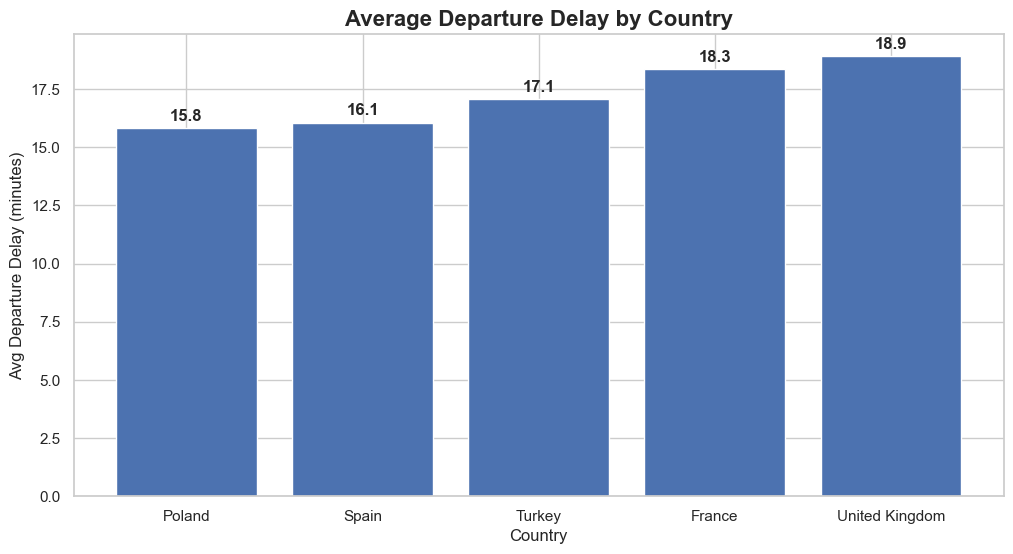

In [54]:
fig, ax = plt.subplots()

country_delay = df.groupby('Country')['Avg Departure Schedule Delay'].mean().sort_values()

bars = ax.bar(country_delay.index, country_delay.values)

ax.set_title('Average Departure Delay by Country', fontsize=16, fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('Avg Departure Delay (minutes)')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{bar.get_height():.1f}', horizontalalignment='center', verticalalignment='bottom', fontweight='bold')

plt.show()

UK and France show the highest average departure delays, while Poland consistently performs better.

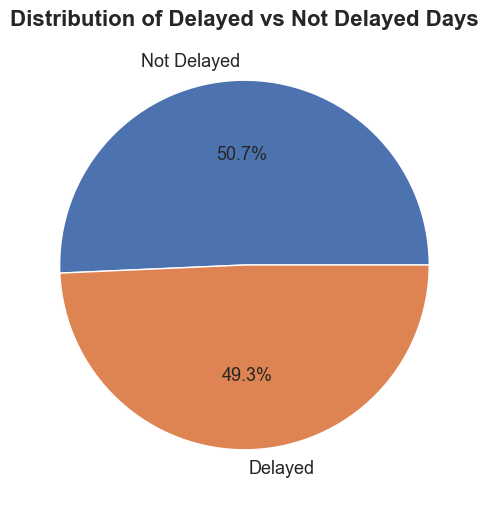

In [55]:
fig, ax = plt.subplots()

counts = df['Delayed'].value_counts()

wedges, texts, autotexts = ax.pie(counts.values, labels=['Not Delayed', 'Delayed'], autopct='%1.1f%%', textprops={'fontsize': 13})

ax.set_title('Distribution of Delayed vs Not Delayed Days', fontsize=16, fontweight='bold')

plt.show()

The dataset shows a class balance, which is good for training the model.

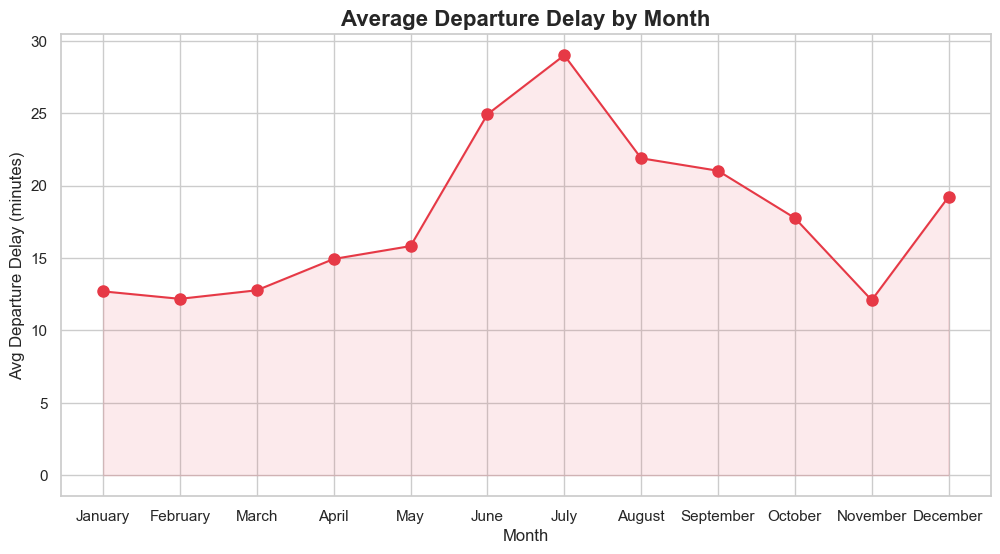

In [60]:
fig, ax = plt.subplots()

month_delay = df.groupby('Month')['Avg Departure Schedule Delay'].mean()
month_names = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

ax.plot(month_delay.index, month_delay.values, 
        marker='o', color='#e63946', markersize=8)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_title('Average Departure Delay by Month', fontsize=16, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Departure Delay (minutes)')
ax.fill_between(month_delay.index, month_delay.values, alpha=0.1, color='#e63946')

plt.show()

Delays peak during summer months, likely caused by higher traffic volumes. December also show elevated delays due to bad weather conditions.

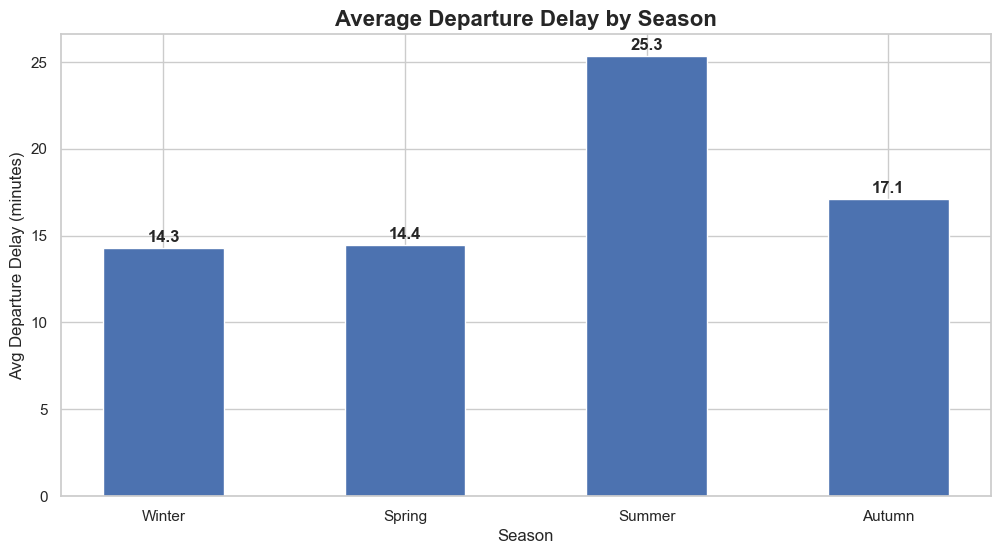

In [64]:
fig, ax = plt.subplots()

season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
season_delay = df.groupby('Season')['Avg Departure Schedule Delay'].mean()
season_delay = season_delay.reindex(season_order)

bars = ax.bar(season_delay.index, season_delay.values, width=0.5)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{bar.get_height():.1f}', horizontalalignment='center', verticalalignment='bottom', fontweight='bold')

ax.set_title('Average Departure Delay by Season', fontsize=16, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Avg Departure Delay (minutes)')

plt.show()

Summer shows the highest average delays, confirming that peak travel season puts significant pressure on airport operations. Autumn follow, while Spring and Winter tend to have the lowest delays.

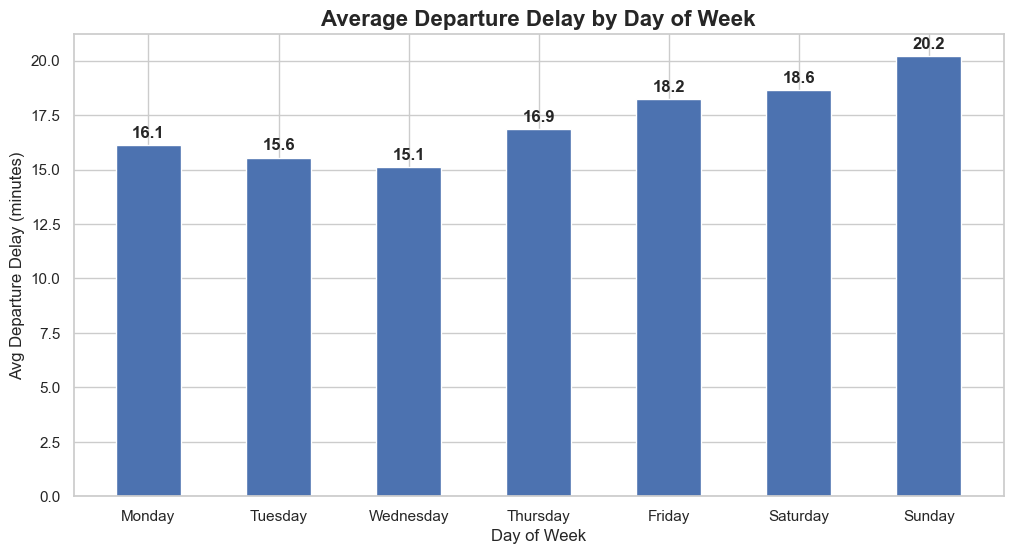

In [66]:
fig, ax = plt.subplots()

weekday_names = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_delay = df.groupby('Weekday')['Avg Departure Schedule Delay'].mean()

ax.bar(weekday_names, weekday_delay.values, width=0.5)

for i, v in enumerate(weekday_delay.values):
    ax.text(i, v + 0.2, f'{v:.1f}', horizontalalignment='center', verticalalignment='bottom', fontweight='bold')

ax.set_title('Average Departure Delay by Day of Week', fontsize=16, fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Avg Departure Delay (minutes)')

plt.show()

Weekends tend to show higher delays due to increased passenger volumes.

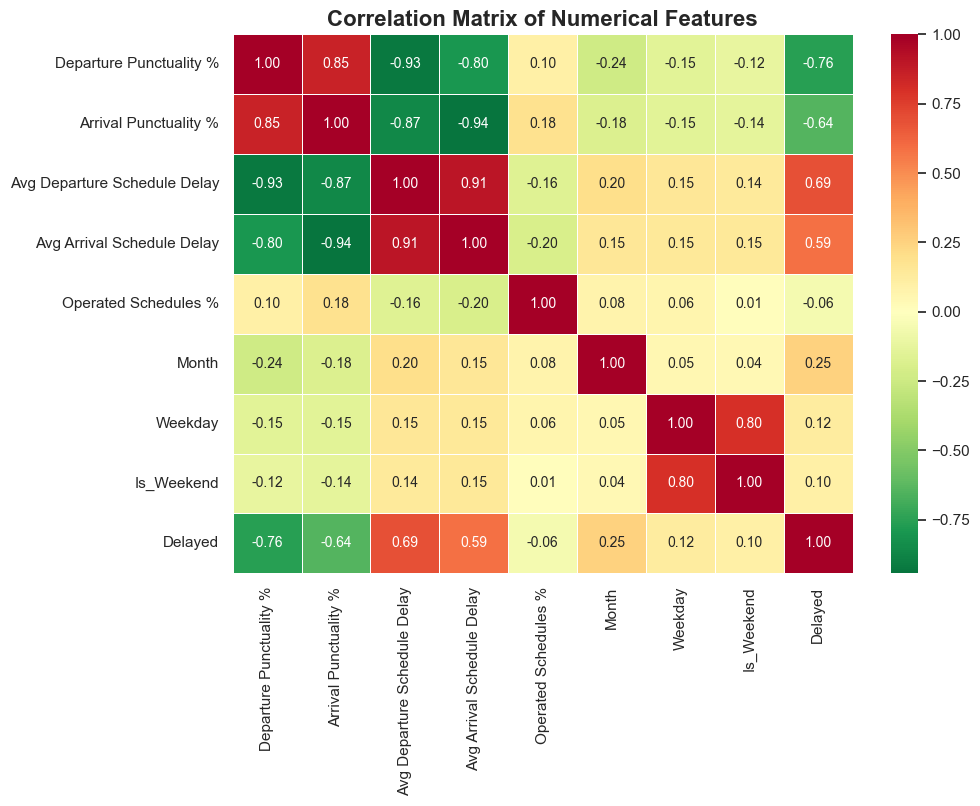

In [69]:
fig, ax = plt.subplots(figsize=(10, 7))

numeric_cols = [
    'Departure Punctuality %', 'Arrival Punctuality %',
    'Avg Departure Schedule Delay', 'Avg Arrival Schedule Delay',
    'Operated Schedules %', 'Month', 'Weekday', 'Is_Weekend', 'Delayed'
]

corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, ax=ax, linewidths=0.5,
            annot_kws={'size': 10})

ax.set_title('Correlation Matrix of Numerical Features', 
             fontsize=16, fontweight='bold')

plt.show()

The Delayed target variable shows the strongest correlation with departure delay and punctuality features.

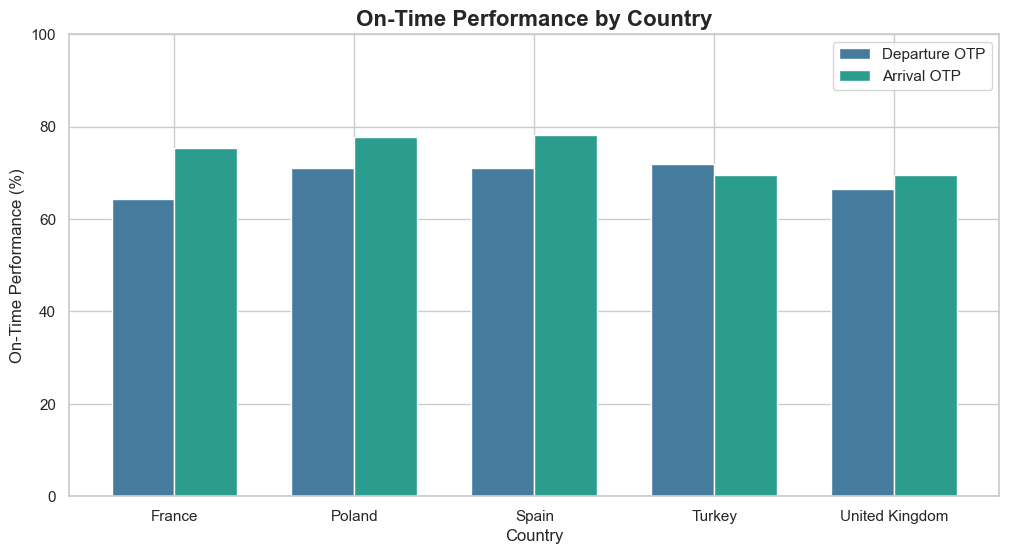

In [73]:
fig, ax = plt.subplots()

country_otp = df.groupby('Country')[['Departure Punctuality %', 'Arrival Punctuality %']].mean()

x = np.arange(len(country_otp.index))
width = 0.35

ax.bar(x - width/2, country_otp['Departure Punctuality %'], 
               width, label='Departure OTP', color='#457b9d')
ax.bar(x + width/2, country_otp['Arrival Punctuality %'], 
               width, label='Arrival OTP', color='#2a9d8f')

ax.set_xticks(x)
ax.set_xticklabels(country_otp.index)
ax.set_title('On-Time Performance by Country', fontsize=16, fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('On-Time Performance (%)')
ax.legend()
ax.set_ylim(0, 100)

plt.show()

Poland and Spain show relatively higher on-time performance compared to Turkey and UK. Across almost of the countries, arrival punctuality is generally slightly higher than departure punctuality.